# Just making an example spike raster plot

this is from one of robert's pretrained models DMS task

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys 

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
import model
from model import generate_input_stim_xor


sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import importlib

2024-12-03 16:14:04.197243: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-03 16:14:04.198169: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-03 16:14:04.200440: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-03 16:14:04.206416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-03 16:14:04.215399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Instructions for updating:
non-resource variables are not supported in the long term


## Rate model

### load model

In [3]:
model_dir = '/scratch/spikeRNN/models/DMS_OSF/'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

### visualize training settings

In [4]:
tr_settings = {
            'T': 500, # trial duration (in steps)
            'stim_on': 200, # input stim onset (in steps)
            'stim_dur': 50, # input stim duration (in steps)
            'delay': 10, # delay before probe (in steps)
            'DeltaT': 1, # sampling rate
            'taus': [4, 25], # decay time-constants (in steps)
            'task': 'xor', # task name
            }

In [5]:
print(f'total training trials: {mat_data["tr"]}')

total training trials: [[3301]]


In [6]:
# get exc and inh indices

exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  2   5   9  26  28  34  35  39  40  51  52  62  63  68  71  73  74  79
  87  91 107 109 110 113 114 117 120 125 128 129 138 140 149 152 156 161
 165 167 174 177 179 185 191 194 196]


### visualize model fr (r) and synaptic current (x)

In [8]:
spk = scipy.io.loadmat('/scratch/spikeRNN/spk_example.mat')
spk = spk['spk']

In [9]:
spk.shape

(200, 50000)

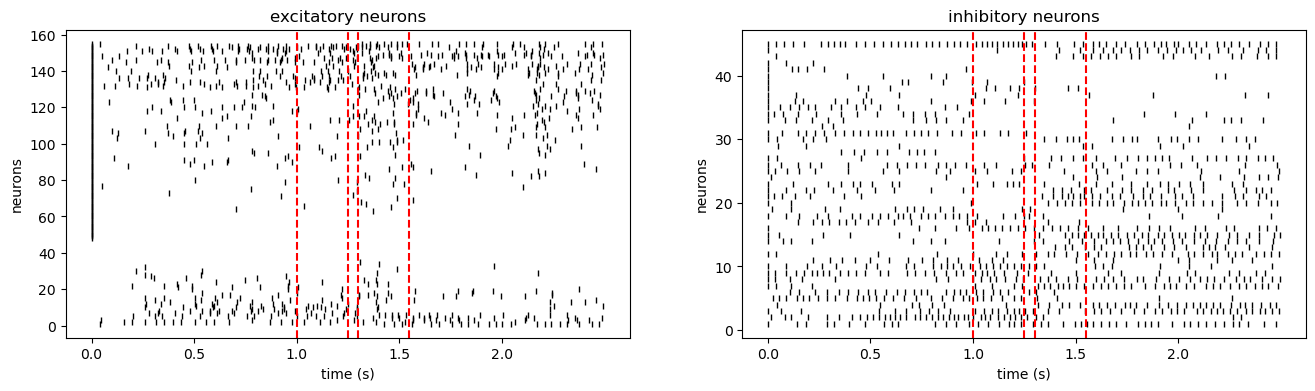

155 excitatory neurons
45 inhibitory neurons


In [34]:
# plot neuron rates

importlib.reload(vu)
vu.plot_neuron_raster(spk, exc_ind, inh_ind, 
                     tr_settings['stim_on']*100, tr_settings['stim_dur']*100, tr_settings['delay']*100, sort=1)

#### plot trajectories

In [12]:
from sklearn.decomposition import PCA

In [14]:
# get 100 trials first
importlib.reload(vu)

n_trials = 100
resp_onset = tr_settings['stim_on'] + tr_settings['stim_dur'] + tr_settings['delay']

r_all = np.zeros((n_trials, r.shape[0], r.shape[1]))
labels = np.zeros(n_trials)
perf = np.zeros(n_trials)
for i in range(n_trials):
    if i < int(n_trials/2):
        label = 1
    else:
        label = -1

    u, label = vu.generate_letters_type(tr_settings['T'], tr_settings['stim_on'],
                                        tr_settings['stim_dur'], tr_settings['delay'], label)
    x, r, o = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=tr_settings, u=u)

    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perf[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perf[i] = 1
    
    labels[i] = label
    r_all[i,:,:] = r

print(f'Performance: {np.mean(perf)}')
print(r_all.shape)
print(f'{np.sum(labels ==1)} trials with label 1')
print(f'{np.sum(labels ==-1)} trials with label -1')

Performance: 0.98
(100, 200, 300)
50 trials with label 1
50 trials with label -1


In [15]:
# mean over trials w same labels
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[labels == 1,:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[labels == -1,:,:], axis=0)
print(r_mean.shape)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


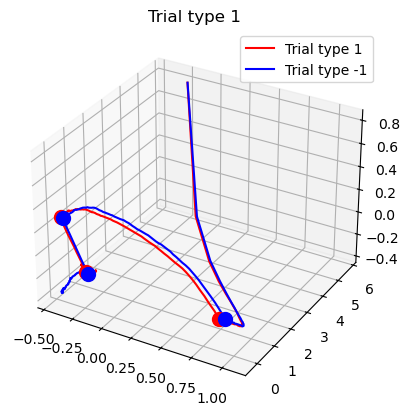

In [16]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[:,i,0], pcs[:,i,1], pcs[:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Trial type {i}')
    ax.legend()
plt.show()

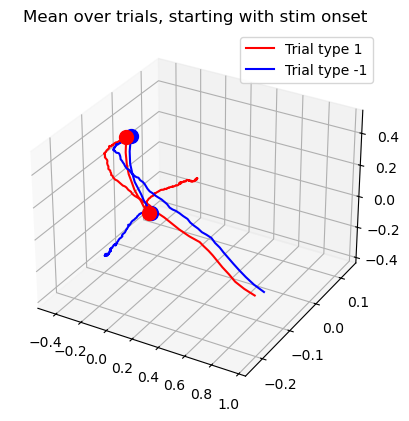

In [25]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
        #  tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10
        ]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Mean over trials, starting with stim onset')
    ax.legend()
plt.show()

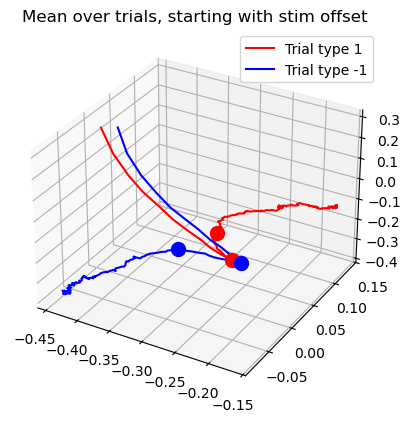

In [24]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10
        ]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[1]:,i,0], pcs[times[1]:,i,1], pcs[times[1]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[2:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Mean over trials, starting with stim offset')
    ax.legend()
plt.show()

#### mean over trials that are correct

In [26]:
# mean over trials w same labels and correct only
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[(labels == 1) & (perf == 1),:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[(labels == -1) & (perf == 1),:,:], axis=0)
print(r_mean.shape)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


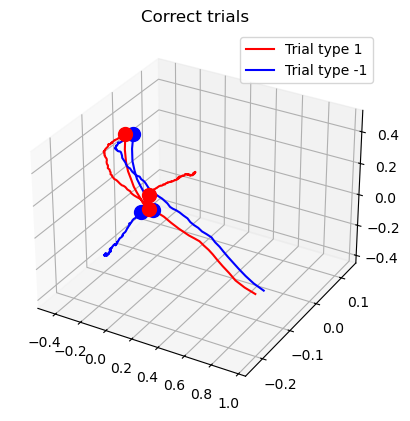

In [27]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Correct trials')
    ax.legend()
plt.show()

#### mean over trials that are incorrect

In [28]:
# mean over trials w same labels and correct only
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[(labels == 1) & (perf == 0),:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[(labels == -1) & (perf == 0),:,:], axis=0)
print(r_mean.shape)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


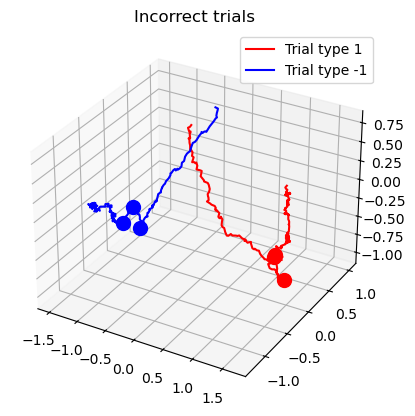

In [29]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Incorrect trials')
    ax.legend()
plt.show()